In [1]:
import os
os.environ["PYTHONWARNINGS"] = "ignore"

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import scanpy as sc
import squidpy as sq
import pickle
import enrichmap as em

In [4]:
sc.set_figure_params(frameon=False)
sc.settings._vector_friendly = False

In [5]:
# set working directory
project_dir = "/home/cenk/Celik_enrichmap/"
working_dir = project_dir + ""
os.chdir(working_dir)

# set figure directory
figure_dir = working_dir + "figures/"

# processed data directory
processed_data = working_dir + "processed_data/"

In [6]:
adata = sc.read_h5ad(processed_data + "adata_slides_0_3.h5ad")

In [7]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [8]:
upregulated_genes = [
    "CFLAR", "CALCOCO1", "YPEL3", "CST3", "SERINC1", "CLIP4", "PCYOX1", "TMEM59","RGS2", "YPEL5", "CD63", "KIAA1109", 
    "CDH13", "GSN", "MR1", "CYB5R1", "AZGP1","ZFYVE1", "DMXL1", "EPS8L2", "PTTG1IP", "MIR22HG", "PSAP", "GOLGA8B", 
    "NEAT1", "TXNIP", "MTRNR2L12"
]

downregulated_genes = [
    "NCAPD2", "PTBP1", "MPHOSPH9", "NUCKS1", "TCOF1", "SART3", "SNRPA", "KIF22", "HSP90AA1", "WBP11", "CAD", "SF3B2",
    "KHSRP", "WDR76", "NUP188", "HSP90AB1", "HNRNPM", "SMARCB1", "PNN", "RBBP7", "NPRL3", "USP10", "SGTA", "MRPL4",
    "PSMD3", "KPNB1", "CBX1", "LRRC59", "TMEM97", "NSD2", "PRPF19", "PTGES3", "CPSF6", "SRSF3", "TCERG1", "SMC4", 
    "EIF4G1", "ZNF142", "MSH6", "MRPL37", "SFPQ", "STMN1", "ARID1A", "PROSER1", "DDX39A", "EXOSC9", "USP22", "DEK",
    "DUT", "ILF3", "DNMT1", "NASP", "HMGB1P5", "SRRM1", "GNL2", "RNF138", "SRSF1", "TRA2B", "SMPD4", "ANP32B", "HMGA1",
    "MDC1", "HADH", "ARHGDIA", "PRCC", "HDGF", "SF3B4", "UBAP2L", "ILF2", "PARP1", "LBR", "CNOT9", "PPRC1", "SSRP1", 
    "CCT5", "DLAT", "HNRNPU", "LARP1", "SCAF4", "RRP1B", "RRP1", "CHCHD4", "GMPS", "RFC4", "SLBP", "PSIP1", "HNRNPK",
    "SKA3", "DIS3L", "USP39", "GPS1", "PA2G4", "HCFC1", "SLC19A1", "ETV4", "RAD23A", "DCTPP1", "RCC1", "EWSR1", "ALYREF",
    "PTMA", "HMGB1", "POM121", "MCMBP", "TEAD4", "CHAMP1", "TOP1", "PRRC2A", "RBM14", "HMGB1P6", "POM121C", "UHRF1"
]
proliferation = ["MKI67", "PCNA", "CCND1", "CCNE1", "CCNA1", "CCNB1", "MCM2", "MCM3", "MCM4", "MCM5", "MCM6", "MCM7", "H3F3A", "H3F3B"]

In [9]:
# dictionary for gene sets
G0_signature = em.tl.build_signed_weights(
    adata, up_genes=upregulated_genes, down_genes=downregulated_genes, score_key="G0"
)

proliferation_signature = {"proliferation": proliferation}

In [10]:
print("Number of upregulated genes: ", len(upregulated_genes))
print("Number of downregulated genes: ", len(downregulated_genes))
print("Number of proliferation genes: ", len(proliferation))

Number of upregulated genes:  27
Number of downregulated genes:  112
Number of proliferation genes:  14


In [11]:
# common genes in proliferation and upregulated genes
common_genes = list(set(upregulated_genes) & set(proliferation))
print("Number of common genes in proliferation and upregulated genes:", len(common_genes))

common_genes = list(set(downregulated_genes) & set(proliferation))
print("Number of common genes in proliferation and downregulated genes:", len(common_genes))

Number of common genes in proliferation and upregulated genes: 0
Number of common genes in proliferation and downregulated genes: 0


In [12]:
em.tl.score(adata, gene_weights=G0_signature, batch_key="batch")
em.tl.score(adata, gene_set=proliferation_signature, batch_key="batch")

Scoring G0: 126/126 genes found:   0%|          | 0/1 [00:00<?, ?it/s]

Scoring proliferation: 14/14 genes found: 100%|██████████| 1/1 [00:03<00:00,  3.70s/it]


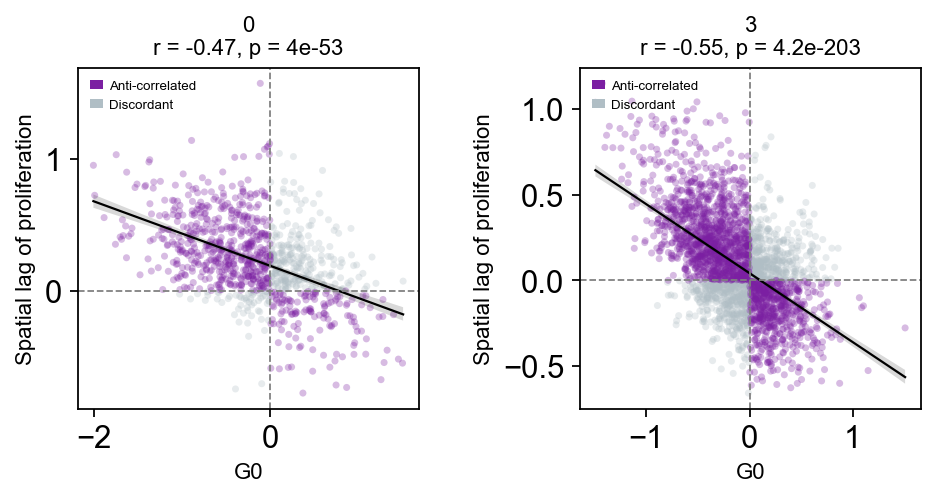

In [13]:
em.pl.cross_moran_scatter(
    adata[adata.obs["tumour_cells"] == 1].copy(),
    score_x="G0_score",
    score_y="proliferation_score",
    library_key="batch",
    save="breast_proliferation_G0_lag_cross_moran_scatter.pdf",
)

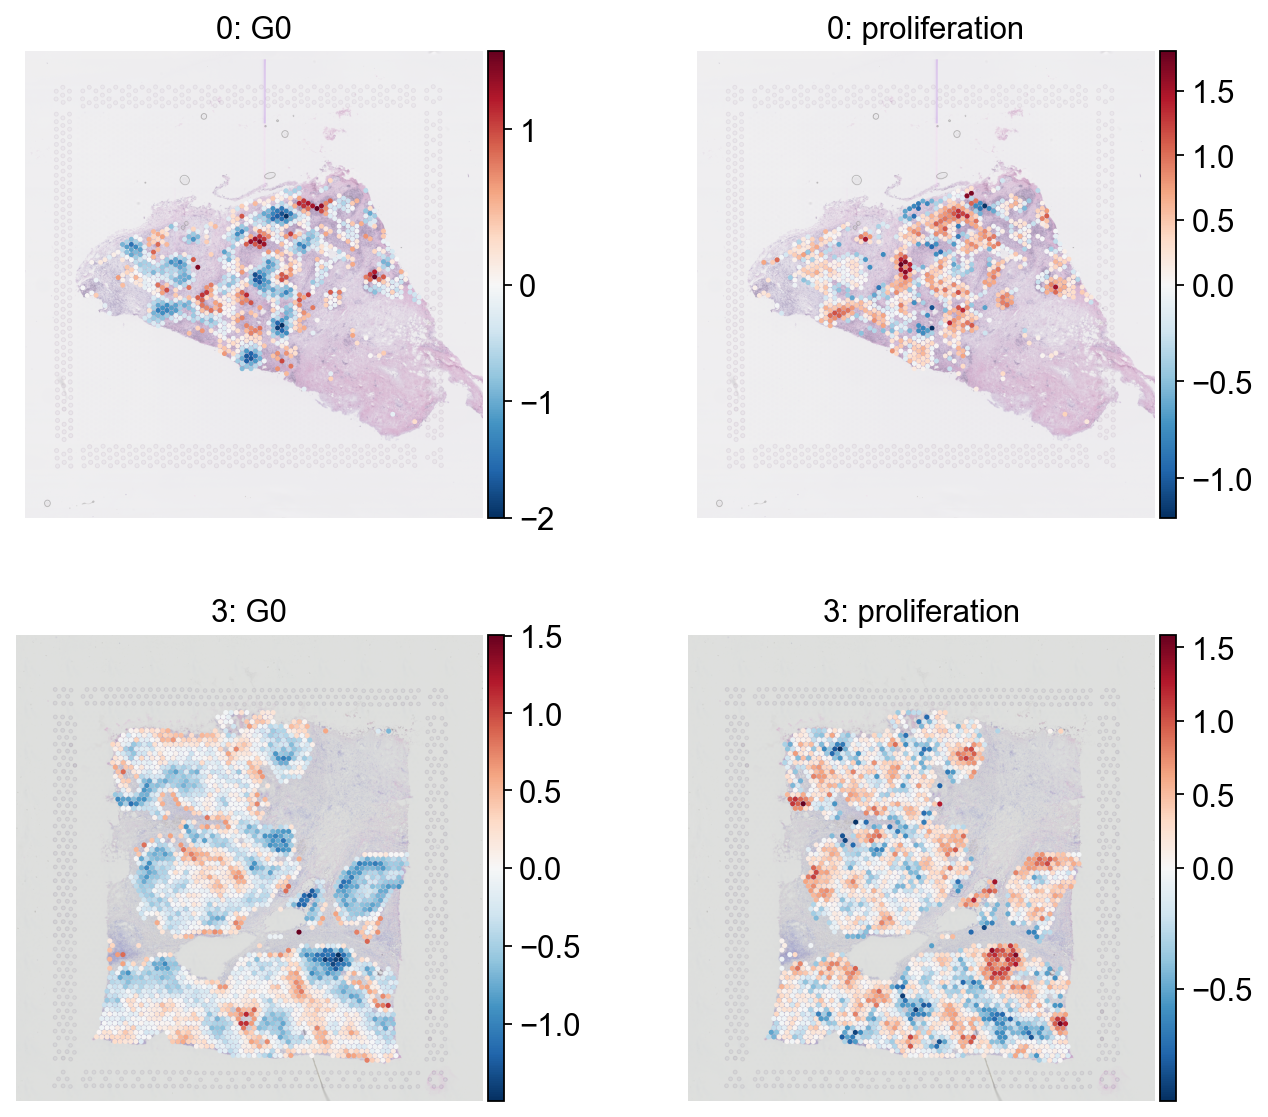

In [14]:
em.pl.spatial_enrichmap(
    adata[adata.obs["tumour_cells"] == 1].copy(),
    score_key=["G0_score", "proliferation_score"],
    library_key="batch", 
    cmap="RdBu_r",
    size=1.5,
    ncols=2,
    save="breast_G0_proliferation_enrichmap.pdf",
)

In [15]:
# read in the pickled gene sets
with open("hallmarks_genelists.pkl", "rb") as f:
    cancer_hallmark_genesets = pickle.load(f)

In [16]:
em.tl.score(adata, gene_set=cancer_hallmark_genesets, batch_key="batch")

Scoring H1: 1144/1332 genes found:   0%|          | 0/13 [00:00<?, ?it/s]

Scoring H13: 341/411 genes found: 100%|██████████| 13/13 [18:10<00:00, 83.86s/it]   


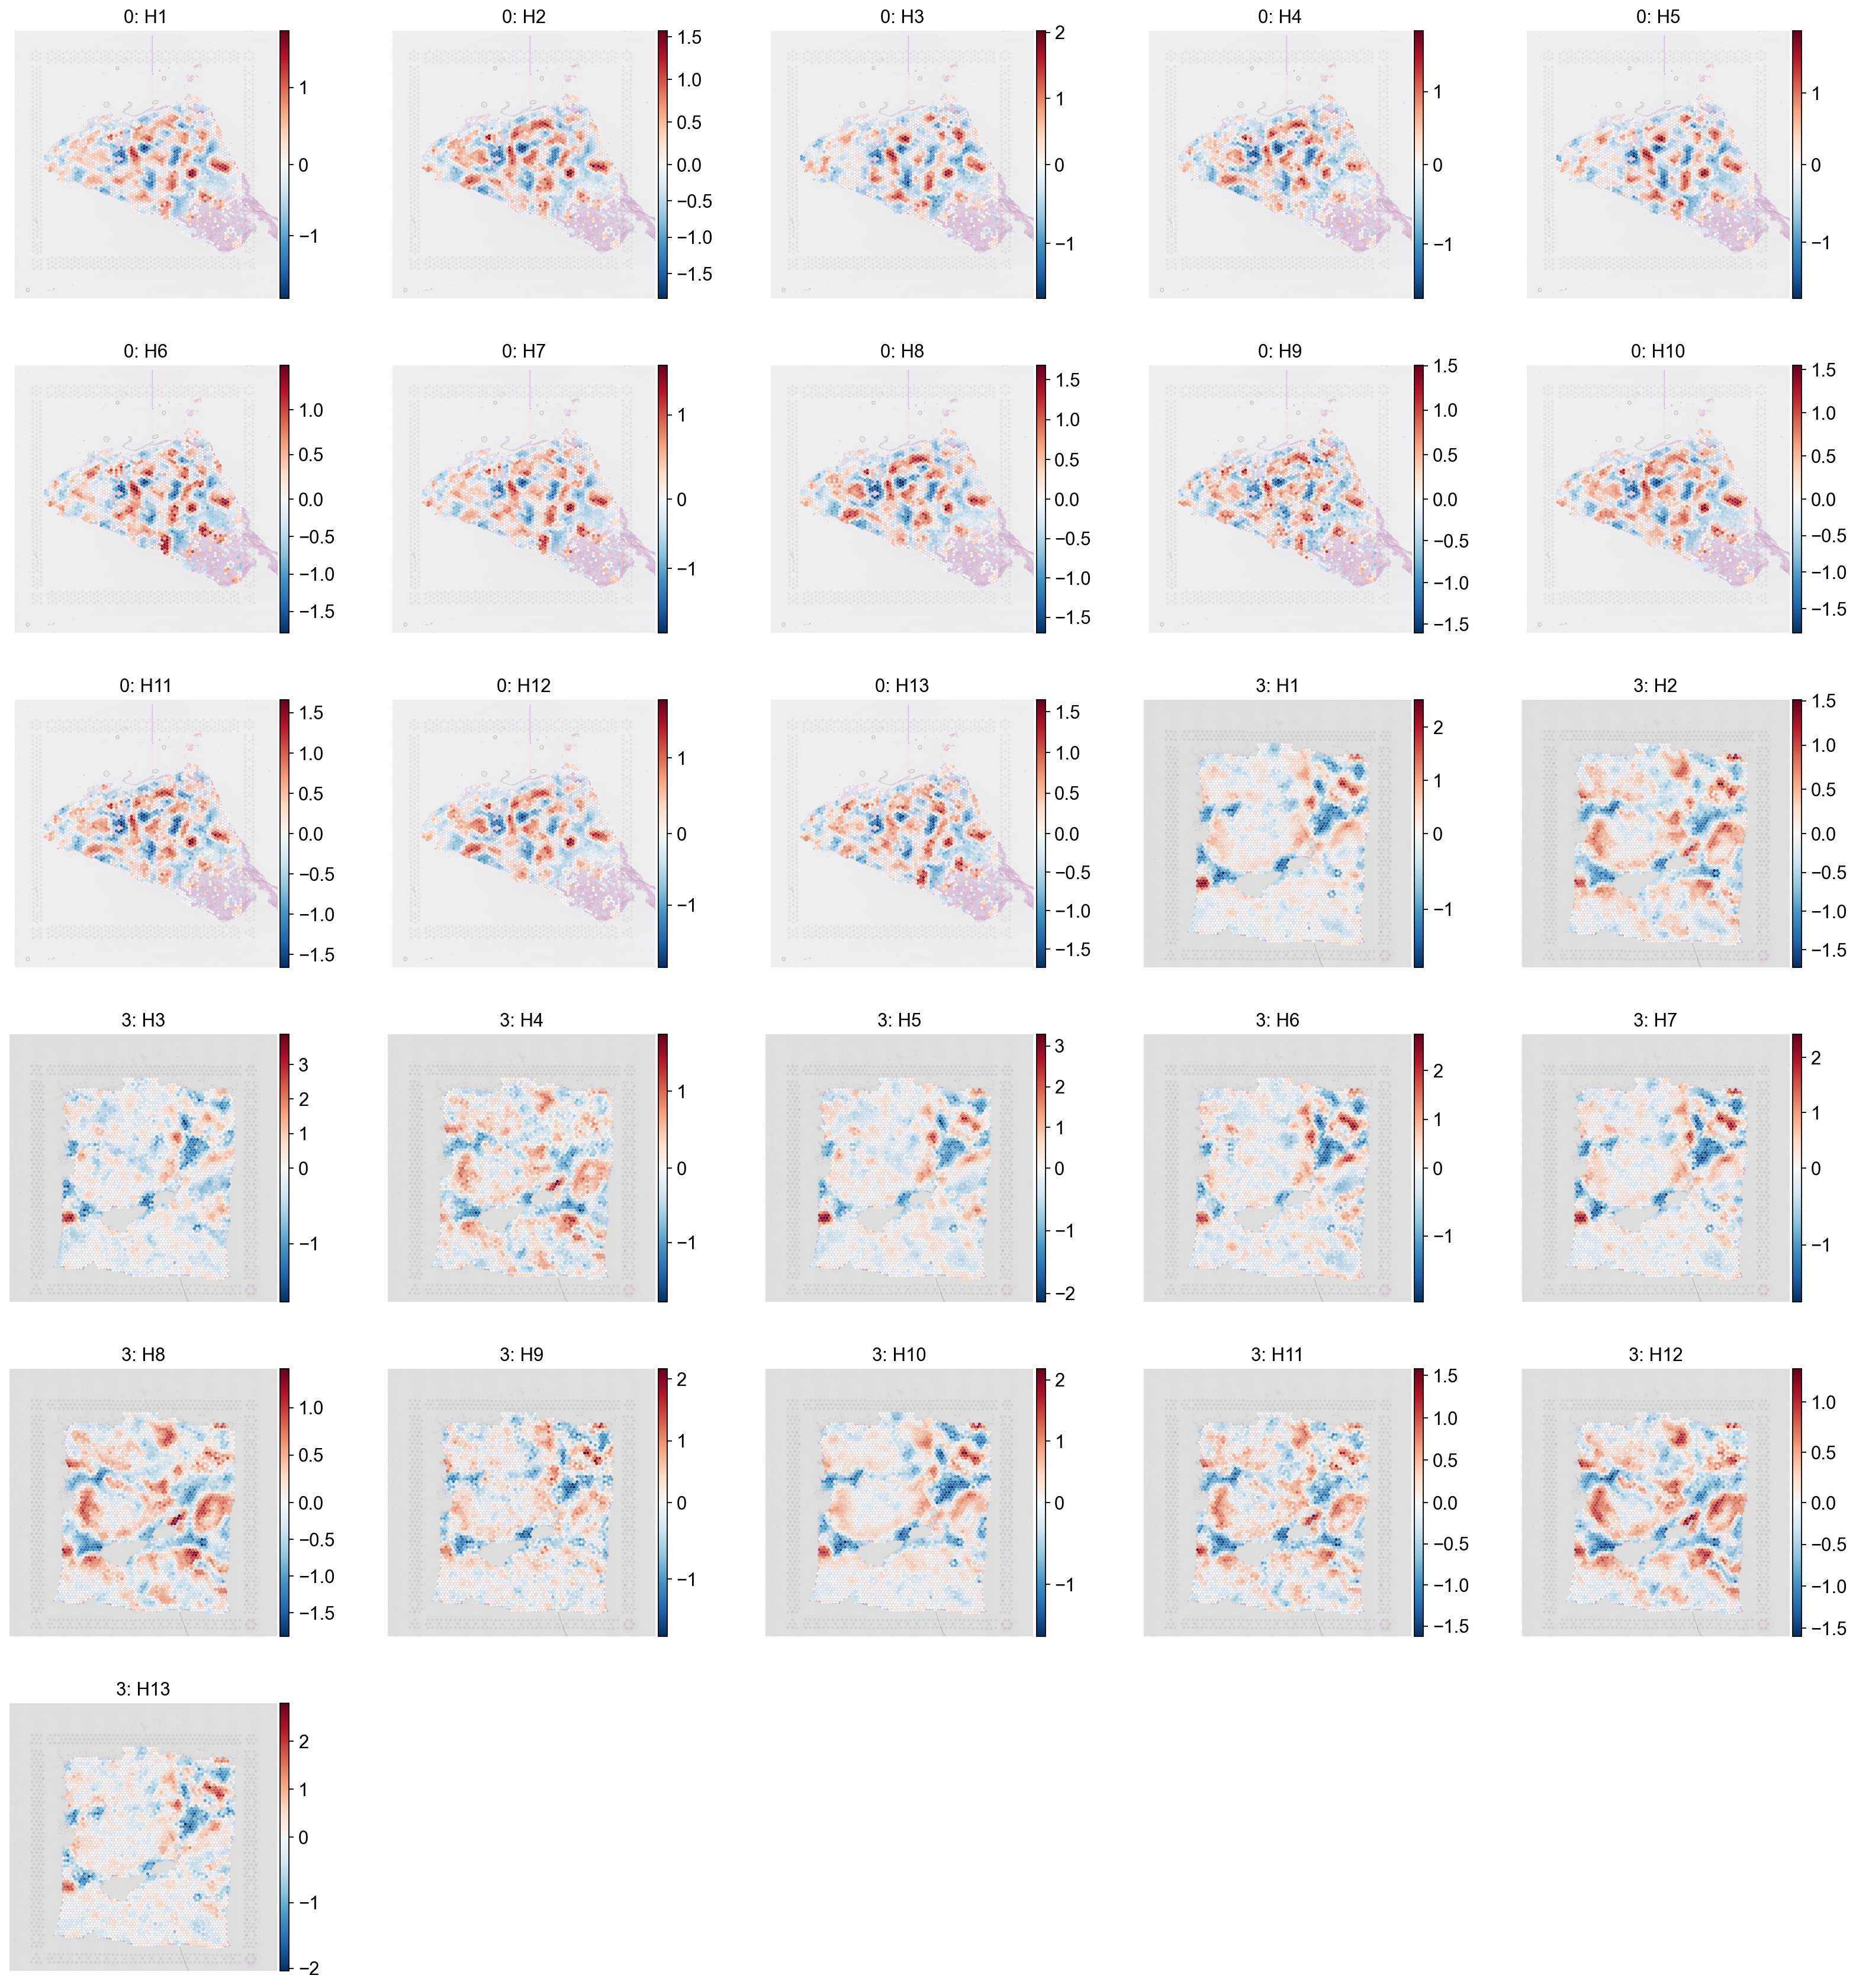

In [17]:
em.pl.spatial_enrichmap(
    adata,
    score_key=[f"{hallmark}_score" for hallmark in cancer_hallmark_genesets.keys()],
    library_key="batch",
    cmap="RdBu_r",
    size=1.5,
    ncols=5,
    save="breast_hallmark_enrichmap.pdf",
)

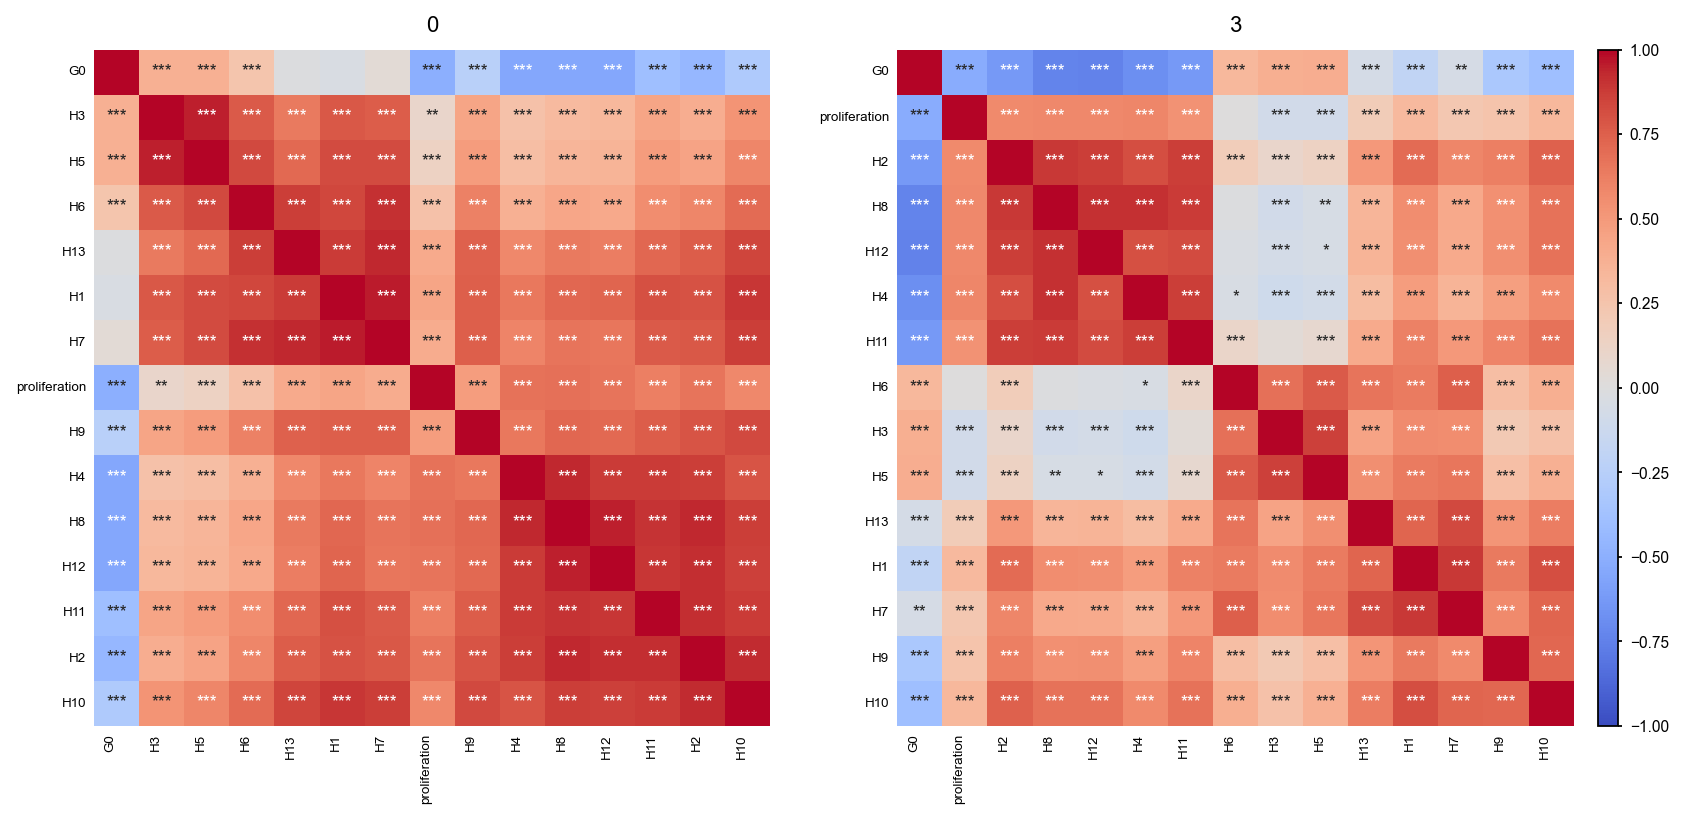

In [18]:
em.pl.signature_correlation_heatmap(
    adata[adata.obs["tumour_cells"] == 1].copy(),
    score_keys=["G0_score", "proliferation_score"] + [f"{hallmark}_score" for hallmark in cancer_hallmark_genesets.keys()],
    library_key="batch",
    save="breast_G0_signature_correlation_heatmap.pdf",
)

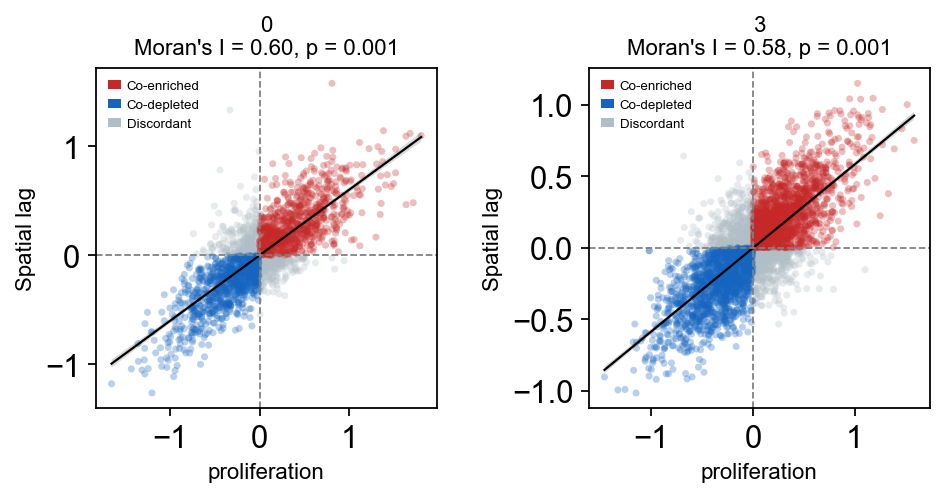

In [19]:
em.pl.morans_correlogram(
    adata,
    score_key="proliferation_score",
    library_key="batch",
    save="breast_proliferation_morans_correlogram.pdf",
)

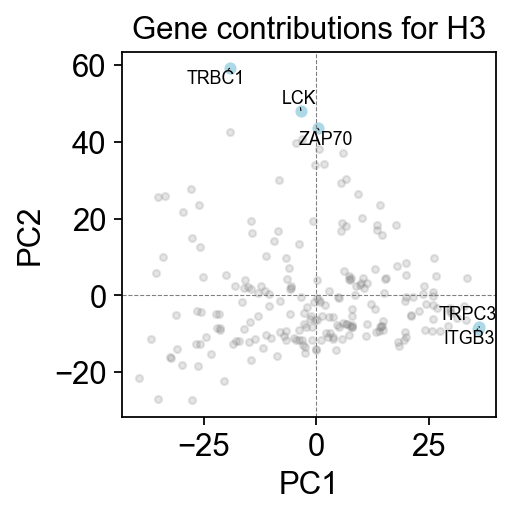

In [20]:
em.pl.gene_contributions_pca(
    adata,
    score_key="H3",
    top_n_genes=5,
    figsize=(3, 3),
    save="breast_H3_contributions_pca.pdf",
)

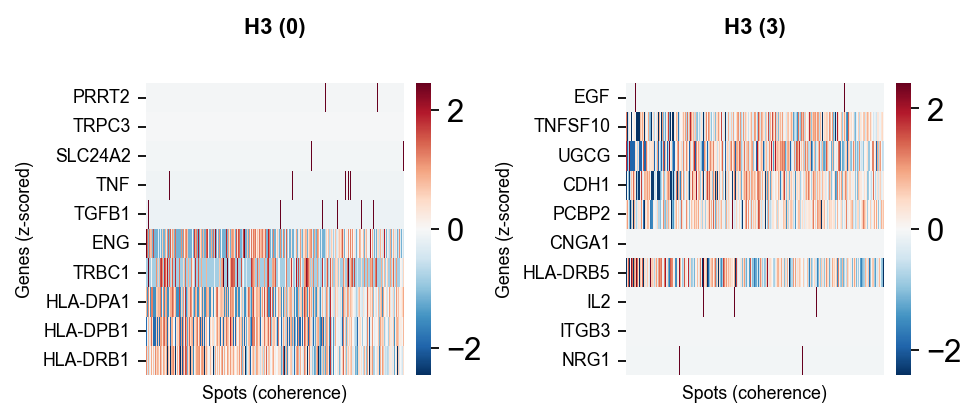

In [21]:
em.pl.gene_contributions_heatmap(
    adata,
    score_key="H3",
    top_n_genes=5,
    bottom_n_genes=5,
    batch_key="batch",
    # groupby=,
    order_spots="coherence",
    figsize=(6, 5),
    cmap="RdBu_r",
    save="breast_H3_contributions_heatmap.pdf",
)

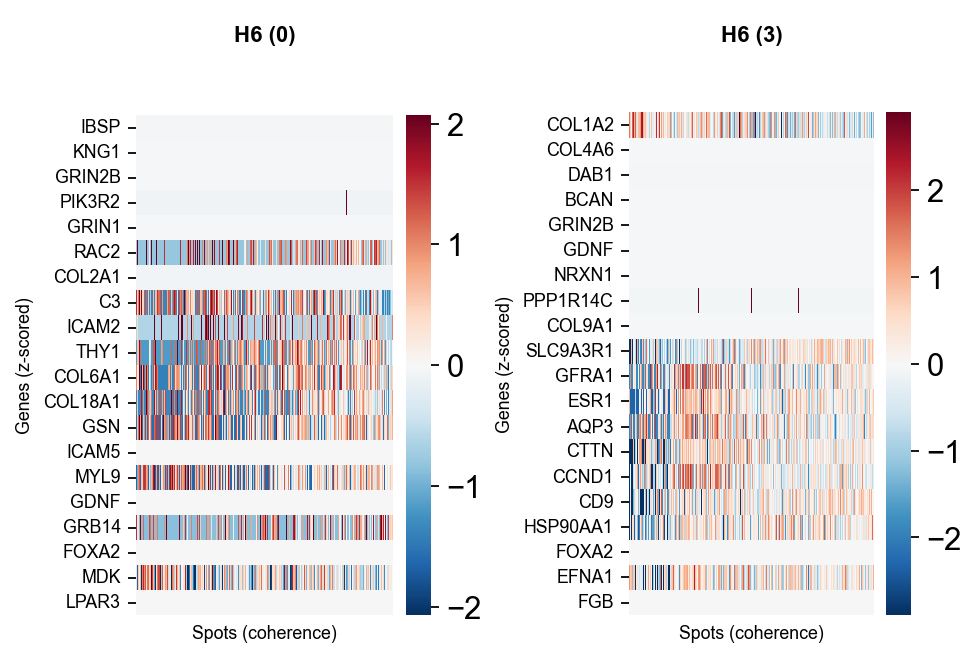

In [22]:
em.pl.gene_contributions_heatmap(
    adata,
    score_key="H6",
    top_n_genes=10,
    bottom_n_genes=10,
    batch_key="batch",
    #groupby="batch",
    order_spots="coherence",
    figsize=(6, 8),
    cmap="RdBu_r",
    save="breast_H6_contributions_heatmap.pdf",
)

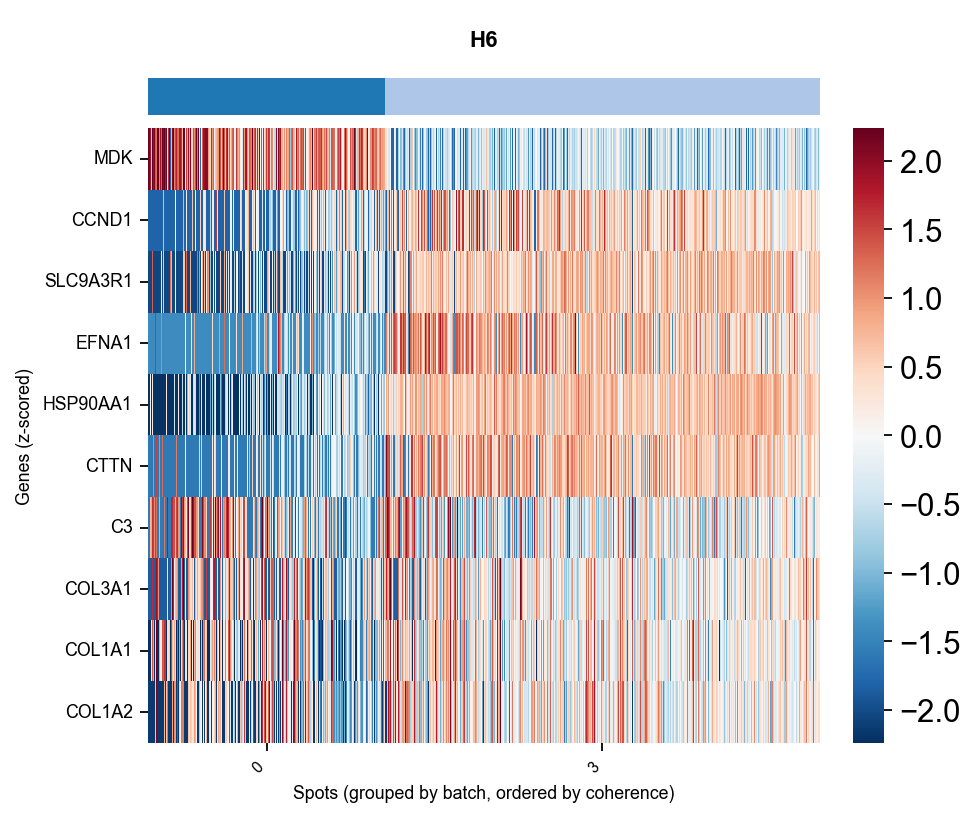

In [23]:
em.pl.gene_contributions_heatmap(
    adata,
    score_key="H6",
    top_n_genes=10,
    bottom_n_genes=0,
    # batch_key="batch",
    groupby="batch",
    order_spots="coherence",
    figsize=(6, 5),
    cmap="RdBu_r",
    save="breast_H6_contributions_heatmap.pdf",
)

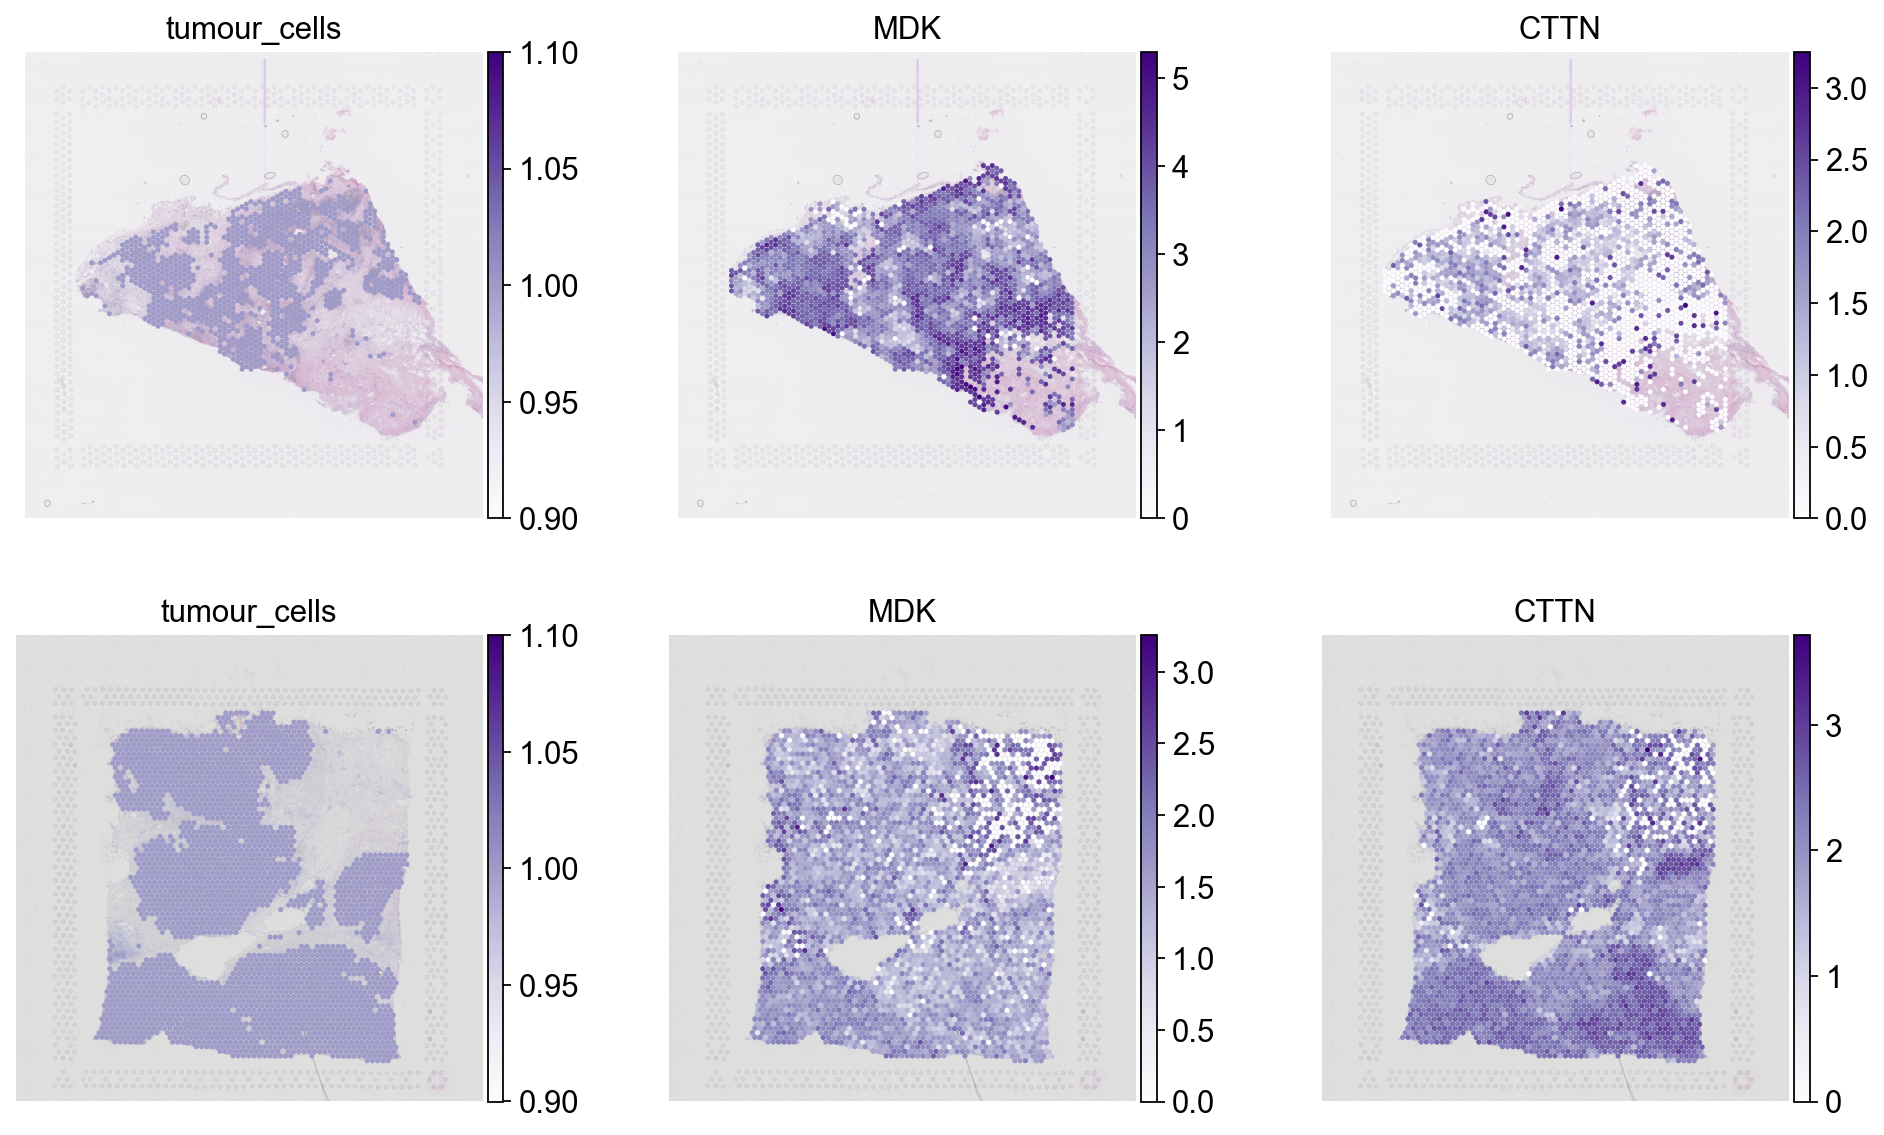

In [24]:
sq.pl.spatial_scatter(
    adata,
    color=["tumour_cells", "MDK", "CTTN"],
    library_key="batch",
    library_id=["0", "3"],
    size=1.5,
    ncols=3,
    img_alpha=0.5,
    cmap="Purples",
    save="breast_tumour_cells_genes.pdf",
)

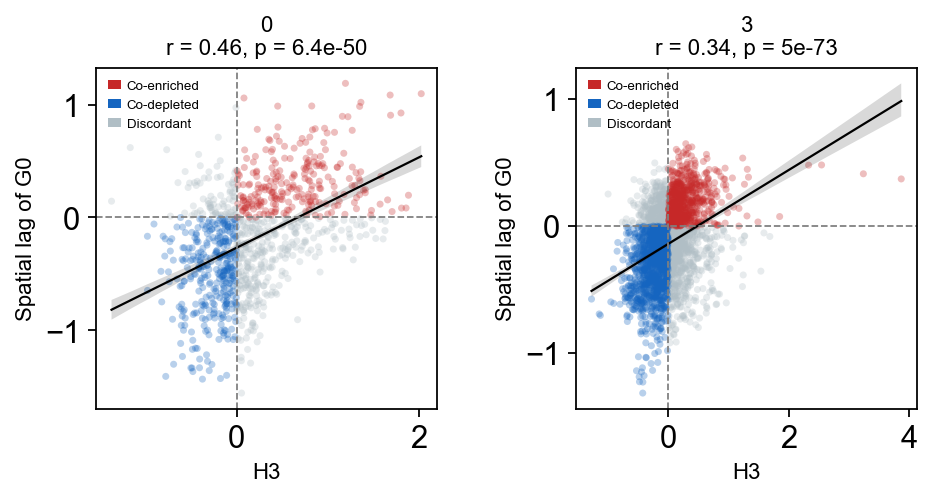

In [25]:
em.pl.cross_moran_scatter(
    adata[adata.obs["tumour_cells"] == 1].copy(),
    score_x="H3_score",
    score_y="G0_score",
    library_key="batch",
    save="breast_H3_G0_cross_moran_scatter.pdf",
)

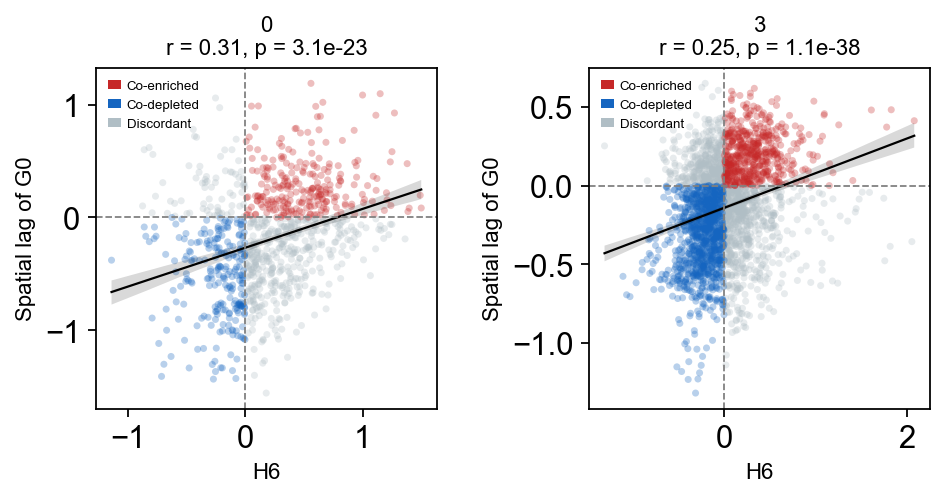

In [26]:
em.pl.cross_moran_scatter(
    adata[adata.obs["tumour_cells"] == 1].copy(),
    score_x="H6_score",
    score_y="G0_score",
    library_key="batch",
    save="breast_H6_G0_cross_moran_scatter.pdf",
)

In [28]:
em.pl.compare_wasserstein(
    adata,
    score_key="H6_score",
    batch_key="batch",
)

Wasserstein distances: 100%|██████████| 1/1 [00:00<00:00,  1.05it/s]


In [ ]:
em.pl.compare_morans_i(
    adata,
    score_key="H6_score",
    batch_key="batch",
)

Moran's I per patient: 100%|██████████| 2/2 [00:00<00:00,  2.46it/s]
